<a href="https://colab.research.google.com/github/D-Barradas/Accelerated-Data-Science-with-RAPIDS/blob/main/part4/4-04_HPO_RayTune_Fractional_GPU_RAPIDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 4.2: High-Throughput HPO using Ray Tune and Fractional GPU Allocation with RAPIDS & PyTorch

**Series:** Accelerated Data Science with RAPIDS — Part 4: Hyperparameter Optimization

## What you will learn

Google Colab typically gives you a single GPU (T4 or L4). Running hyperparameter optimization (HPO) trials one at a time on that single GPU wastes most of its compute and memory capacity, because a small-to-medium PyTorch model rarely saturates a modern GPU on its own. This notebook shows how to:

1. Generate and feature-engineer a large (500k+ row) synthetic time-series dataset entirely on the GPU using **cuDF**, so preprocessing never becomes the bottleneck.
2. Move that data from cuDF into PyTorch-compatible tensors efficiently.
3. Define a small, configurable 1D-CNN / LSTM forecasting model.
4. Use **Ray Tune** with **fractional GPU allocation** (`gpu=0.33`) to pack **three concurrent PyTorch trials onto one physical GPU**, and use the **ASHA scheduler** to kill unpromising trials early so the GPU time we save is reinvested in more promising configurations.

By the end, you'll understand *why* fractional GPU scheduling + early stopping is one of the highest-leverage techniques for doing serious HPO on a single-GPU budget (Colab, a laptop, or a single cloud instance).

## 1. Setup & Environment Verification

Run the cell below once per Colab session. We pin `cudf-cu12` from NVIDIA's package index (RAPIDS wheels are not on the default PyPI index) and install `ray[tune]` for the HPO framework. `torch` ships pre-installed on Colab GPU runtimes with CUDA already wired up, but we install/upgrade it explicitly so this notebook is reproducible outside Colab too.

> **Tip:** If `cudf`/`ray` fail to import right after installing, use **Runtime -> Restart runtime** (not "restart and run all") and re-run from the top — this clears any partially-initialized CUDA context left by the installer.

In [1]:
# !pip -q install torch torchvision scikit-learn matplotlib pandas
!pip -q install "ray[tune]"

# RAPIDS for CUDA 12 (best effort for Colab).
# !pip -q install --extra-index-url=https://pypi.nvidia.com cudf-cu12 cuml-cu12 cupy-cuda12x || true

In [2]:
# Verify the GPU, PyTorch/CUDA, and RAPIDS/Ray versions before doing any real work.
# Failing fast here saves time versus discovering a broken environment mid-training.
import subprocess

import cudf
import ray
import torch

print("=" * 60)
print("GPU (nvidia-smi)")
print("=" * 60)
try:
    smi = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.total,driver_version", "--format=csv,noheader"],
        capture_output=True, text=True, check=True,
    )
    print(smi.stdout)
except (FileNotFoundError, subprocess.CalledProcessError) as exc:
    print(f"nvidia-smi unavailable: {exc}. Make sure the Colab runtime type is set to GPU.")

print("=" * 60)
print("Library versions")
print("=" * 60)
print(f"torch             : {torch.__version__}")
print(f"torch.cuda avail  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"torch CUDA device : {torch.cuda.get_device_name(0)}")
    print(f"torch CUDA version: {torch.version.cuda}")
print(f"cudf              : {cudf.__version__}")
print(f"ray               : {ray.__version__}")

assert torch.cuda.is_available(), (
    "No CUDA device found. In Colab: Runtime -> Change runtime type -> Hardware accelerator -> GPU (T4/L4)."
)

GPU (nvidia-smi)
Tesla T4, 15360 MiB, 580.82.07

Library versions
torch             : 2.11.0+cu128
torch.cuda avail  : True
torch CUDA device : Tesla T4
torch CUDA version: 12.8
cudf              : 26.02.01
ray               : 2.56.1


## 2. Accelerated Data Pipeline with cuDF

We simulate a realistic **multi-entity sensor/financial time series**: many independent entities (e.g. machines, tickers, IoT sensors), each sampled at regular intervals, each producing a noisy signal with its own baseline level, trend, and seasonality.

All feature engineering — rolling statistics, lag features, and grouped/categorical aggregates — is done with **cuDF**, so a 500k-row dataset that would take tens of seconds with pandas `groupby().rolling()` finishes in a fraction of a second on the GPU. This matters because in a real HPO workflow you often re-run preprocessing many times while iterating on features; a slow CPU pipeline directly taxes your GPU-trial throughput budget.

In [3]:
# Core imports used throughout the rest of the notebook.
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.dlpack import from_dlpack

from ray import tune, train
from ray.tune.schedulers import ASHAScheduler

In [4]:
# Generate a synthetic multi-entity time-series dataset directly as a cuDF DataFrame.
# 200 entities x 2,500 timesteps = 500,000 rows.
N_ENTITIES = 200
N_TIMESTEPS = 2_500
SEED = 42

cp.random.seed(SEED)

entity_ids = cp.repeat(cp.arange(N_ENTITIES, dtype=cp.int32), N_TIMESTEPS)
timesteps = cp.tile(cp.arange(N_TIMESTEPS, dtype=cp.int32), N_ENTITIES)

# Each entity has its own random baseline level and slow drift/trend.
entity_baseline = cp.random.normal(loc=0.0, scale=5.0, size=N_ENTITIES).repeat(N_TIMESTEPS)
entity_trend = cp.random.normal(loc=0.0, scale=0.01, size=N_ENTITIES).repeat(N_TIMESTEPS)

# Signal = baseline + slow trend + seasonality + noise.
seasonality = 3.0 * cp.sin(2 * cp.pi * timesteps / 50.0)
noise = cp.random.normal(loc=0.0, scale=1.0, size=N_ENTITIES * N_TIMESTEPS)
value = entity_baseline + entity_trend * timesteps + seasonality + noise

gdf = cudf.DataFrame({
    "entity_id": entity_ids,
    "timestamp": timesteps,
    "value": value.astype(cp.float32),
})

# cuDF requires data sorted-by-group for correct rolling/lag semantics.
gdf = gdf.sort_values(["entity_id", "timestamp"]).reset_index(drop=True)

print(f"Rows: {len(gdf):,}")
gdf.head()

Rows: 500,000


,entity_id,timestamp,value
0,0,0,-1.625177
1,0,1,-0.587978
2,0,2,0.119859
3,0,3,0.785505
4,0,4,-0.117627


In [5]:
# Feature engineering on GPU: rolling stats, lag features, and grouped/categorical aggregates.
# Everything here runs as a groupby-rolling / groupby-transform directly on the GPU with cuDF.
ROLL_WINDOW = 10

grouped = gdf.groupby("entity_id", sort=False)

# Rolling window aggregations: per-entity moving average and standard deviation of the signal.
gdf["roll_mean"] = grouped["value"].rolling(ROLL_WINDOW, min_periods=1).mean().reset_index(drop=True)
gdf["roll_std"] = grouped["value"].rolling(ROLL_WINDOW, min_periods=1).std().reset_index(drop=True)
gdf["roll_std"] = gdf["roll_std"].fillna(0.0)

# Lag features: value at t-1, t-2, t-3 (per entity, no cross-entity leakage).
for lag in (1, 2, 3):
    gdf[f"lag_{lag}"] = grouped["value"].shift(lag).reset_index(drop=True)
gdf[["lag_1", "lag_2", "lag_3"]] = gdf[["lag_1", "lag_2", "lag_3"]].bfill()

# Grouped/categorical feature: overall per-entity mean, broadcast back onto every row.
# This is the classic "categorical -> aggregate" feature pattern used in tabular ML pipelines.
gdf["entity_mean"] = grouped["value"].transform("mean")

# Forecasting target: next-step value (what the model predicts from the trailing window).
gdf["target"] = grouped["value"].shift(-1).reset_index(drop=True)

# Drop the last timestep per entity (no target available) and any residual NaNs.
gdf = gdf.dropna().reset_index(drop=True)

print(f"Rows after feature engineering: {len(gdf):,}")
gdf.head()

Rows after feature engineering: 499,800


,entity_id,timestamp,value,roll_mean,roll_std,lag_1,lag_2,lag_3,entity_mean,target
0,0,0,-1.625177,-1.625177,0.000000,-1.625177,-1.625177,-1.625177,-23.710177,-0.587978
1,0,1,-0.587978,-1.106577,0.733410,-1.625177,-1.625177,-1.625177,-23.710177,0.119859
2,0,2,0.119859,-0.697765,0.877683,-0.587978,-1.625177,-1.625177,-23.710177,0.785505
3,0,3,0.785505,-0.326948,1.031297,0.119859,-0.587978,-1.625177,-23.710177,-0.117627
4,0,4,-0.117627,-0.285083,0.898022,0.785505,0.119859,-0.587978,-23.710177,-0.336711


### From tabular rows to fixed-length sequences

The forecasting model needs a contiguous trailing window of `SEQ_LEN` timesteps per training example. We build these windows with vectorized GPU array indexing (broadcasted fancy indexing) instead of a Python-level loop, so this step scales cleanly to the full 500k-row dataset.

In [6]:
# Build fixed-length sequences (sliding windows) for the forecasting model.
#
#   1. Number rows within each entity (row_id = 0..n_i-1).
#   2. Keep rows whose row_id >= SEQ_LEN - 1 (enough history exists).
#   3. Gather SEQ_LEN-length windows via broadcasted fancy indexing on the feature matrix.
SEQ_LEN = 24
FEATURE_COLS = ["value", "roll_mean", "roll_std", "lag_1", "lag_2", "lag_3", "entity_mean"]

gdf["row_id"] = grouped.cumcount()

# Feature matrix and targets as CuPy arrays (zero-copy view from cuDF).
feature_matrix = gdf[FEATURE_COLS].to_cupy(dtype=cp.float32)
targets = gdf["target"].to_cupy(dtype=cp.float32)
row_id = gdf["row_id"].to_cupy(dtype=cp.int32)

valid_mask = row_id >= (SEQ_LEN - 1)
end_indices = cp.nonzero(valid_mask)[0]  # global row index of the *last* step in each window

# window_indices[i] = [end_indices[i] - SEQ_LEN + 1, ..., end_indices[i]]
offsets = cp.arange(SEQ_LEN, dtype=cp.int32) - (SEQ_LEN - 1)
window_indices = end_indices[:, None] + offsets[None, :]

X = feature_matrix[window_indices]          # shape: (n_sequences, SEQ_LEN, n_features)
y = targets[end_indices]                    # shape: (n_sequences,)

print(f"Sequence tensor X: {X.shape}, target vector y: {y.shape}")

Sequence tensor X: (495200, 24, 7), target vector y: (495200,)


In [7]:
# Normalize features (zero mean / unit variance) and hold out a validation split.
# Normalization statistics are computed on the *training* split only, to avoid leakage.
N = X.shape[0]
n_val = int(0.2 * N)
perm = cp.random.permutation(N)
train_idx, val_idx = perm[n_val:], perm[:n_val]

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

feat_mean = X_train.reshape(-1, X_train.shape[-1]).mean(axis=0)
feat_std = X_train.reshape(-1, X_train.shape[-1]).std(axis=0) + 1e-6
X_train = (X_train - feat_mean) / feat_std
X_val = (X_val - feat_mean) / feat_std

target_mean, target_std = y_train.mean(), y_train.std() + 1e-6
y_train = (y_train - target_mean) / target_std
y_val = (y_val - target_mean) / target_std

print(f"Train sequences: {X_train.shape[0]:,} | Val sequences: {X_val.shape[0]:,}")

Train sequences: 396,160 | Val sequences: 99,040


### Handing data to PyTorch

We convert the CuPy arrays to host NumPy arrays before building `TensorDataset`/`DataLoader` objects. We move to host memory at this point because **Ray Tune trials run in separate worker processes**: a `DataLoader` holding live CUDA tensors cannot be pickled and shared across process boundaries, so each trial reconstructs its own `DataLoader` from shared NumPy arrays (Section 4) and moves batches to its assigned GPU fraction itself.

In [ ]:
# Create CPU-resident NumPy arrays for Ray Tune (multi-process HPO)
# We must use .get() to physically move the data from GPU memory to Host memory
X_train_np = X_train.get()
y_train_np = y_train.get()
X_val_np = X_val.get()
y_val_np = y_val.get()

print(f"CPU Arrays:  X_train_np type: {type(X_train_np)}")

GPU Tensors: X_train_torch on cuda:0
CPU Arrays:  X_train_np type: <class 'numpy.ndarray'>


## 3. PyTorch Model Definition

We define a single modular `SequenceForecastNet` that can act as **either a 1D-CNN or an LSTM** encoder over the trailing `SEQ_LEN`-step window, followed by a small MLP regression head. Which encoder is used, how wide/deep it is, and its dropout rate are all constructor arguments — this lets Ray Tune treat the architecture family itself as a tunable hyperparameter, not just its size.

In [9]:
class SequenceForecastNet(nn.Module):
    """Configurable 1D-CNN / LSTM encoder for single-step time-series forecasting.

    Parameters
    ----------
    n_features : number of input features per timestep.
    hidden_size : width of the encoder (CNN channels or LSTM hidden units).
    num_layers : depth of the encoder.
    dropout : dropout probability applied inside the encoder / before the regression head.
    model_type : "lstm" or "cnn" - selects the sequence encoder architecture.
    """

    def __init__(self, n_features: int, hidden_size: int = 64, num_layers: int = 2,
                 dropout: float = 0.2, model_type: str = "lstm"):
        super().__init__()
        self.model_type = model_type

        if model_type == "lstm":
            self.encoder = nn.LSTM(
                input_size=n_features,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
            )
        elif model_type == "cnn":
            channels = [n_features] + [hidden_size] * num_layers
            conv_layers = []
            for in_ch, out_ch in zip(channels[:-1], channels[1:]):
                conv_layers += [
                    nn.Conv1d(in_ch, out_ch, kernel_size=3, padding=1),
                    nn.ReLU(),
                    nn.Dropout(dropout),
                ]
            self.encoder = nn.Sequential(*conv_layers)
        else:
            raise ValueError(f"Unknown model_type: {model_type!r} (expected 'lstm' or 'cnn')")

        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, n_features)
        if self.model_type == "lstm":
            _, (h_n, _) = self.encoder(x)
            encoded = h_n[-1]                          # last layer's final hidden state
        else:
            encoded = self.encoder(x.transpose(1, 2))   # -> (batch, channels, seq_len)
            encoded = encoded.mean(dim=-1)               # global average pool over time
        return self.head(encoded).squeeze(-1)

In [10]:
# Quick sanity check: one forward pass with random weights on CPU, for both architectures.
for _model_type in ("lstm", "cnn"):
    _sanity_model = SequenceForecastNet(n_features=len(FEATURE_COLS), model_type=_model_type)
    _sanity_out = _sanity_model(torch.from_numpy(X_train_np[:8]))
    assert _sanity_out.shape == (8,), f"Unexpected output shape: {_sanity_out.shape}"
    print(f"{_model_type} forward pass OK: output shape {tuple(_sanity_out.shape)}")

lstm forward pass OK: output shape (8,)
cnn forward pass OK: output shape (8,)


## 4. Ray Tune Integration & Fractional GPU Allocation

**Why fractional GPUs?** A single trial of this model uses only a small fraction of a T4/L4's compute and a few hundred MB of memory — running one trial at a time would leave most of the GPU idle. Ray Tune lets you declare *fractional* GPU requirements per trial (e.g. `gpu=0.33`); Ray then **co-schedules multiple trials on the same physical GPU**, each with its own CUDA context, as long as the fractions requested sum to at most 1 per GPU. With `gpu=0.33` we can run **3 trials concurrently** on Colab's single GPU — roughly a 3x increase in HPO throughput for free.

**Why ASHA?** Successive-halving schedulers like ASHA monitor each trial's intermediate metrics and terminate the worst-performing trials early, before they consume their full epoch budget. Combined with fractional GPUs, this means the GPU slots freed by killed trials are immediately reused by new configurations — maximizing the number of configurations explored per unit of wall-clock time.

In [11]:
# Initialize a local Ray cluster sized for Colab's resource limits.
# `ignore_reinit_error=True` lets you re-run this cell without restarting the kernel.
import multiprocessing

ray.shutdown()  # ensure a clean slate if this cell is re-run
ray.init(
    num_cpus=multiprocessing.cpu_count(),
    num_gpus=1 if torch.cuda.is_available() else 0,
    ignore_reinit_error=True,
    log_to_driver=False,  # keep trial logs from flooding the notebook output
)
print(ray.cluster_resources())

2026-08-05 14:53:43,301	INFO worker.py:2024 -- Started a local Ray instance.


{'node:__internal_head__': 1.0, 'CPU': 2.0, 'memory': 9220943872.0, 'node:172.28.0.12': 1.0, 'object_store_memory': 3951833088.0, 'GPU': 1.0, 'accelerator_type:T4': 1.0}


In [12]:
def train_forecast(config: dict, X_train, y_train, X_val, y_val):
    """Train one SequenceForecastNet configuration and report metrics each epoch."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = SequenceForecastNet(
        n_features=X_train.shape[-1],
        hidden_size=config["hidden_size"],
        num_layers=config["num_layers"],
        dropout=config["dropout"],
        model_type=config["model_type"],
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    criterion = nn.MSELoss()

    train_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
        batch_size=config["batch_size"], shuffle=True, drop_last=True,
    )
    val_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val)),
        batch_size=config["batch_size"], shuffle=False,
    )

    for epoch in range(config.get("max_epochs", 15)):
        model.train()
        train_loss_total, train_batches = 0.0, 0
        try:
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                optimizer.step()
                train_loss_total += loss.item()
                train_batches += 1
        except RuntimeError as exc:
            if "out of memory" not in str(exc).lower():
                raise
            torch.cuda.empty_cache()
            # Use tune.report to avoid DeprecationWarning crash
            tune.report({
                'val_loss':float("inf"),
                'train_loss':float("inf"),
                'epoch':epoch,
                'oom':True})
            return

        model.eval()
        val_loss_total, val_batches = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss_total += criterion(model(xb), yb).item()
                val_batches += 1

        # Use tune.report to avoid DeprecationWarning crash
        # And use a Dictionary
        tune.report({
            'train_loss':train_loss_total / max(train_batches, 1),
            'val_loss':val_loss_total / max(val_batches, 1),
            'epoch':epoch,
        })

In [13]:
# Hyperparameter search space.
search_space = {
    "lr": tune.loguniform(1e-4, 1e-2),
    "batch_size": tune.choice([64, 128, 256]),
    "dropout": tune.uniform(0.0, 0.5),
    "hidden_size": tune.choice([32, 64, 128]),
    "num_layers": tune.choice([1, 2]),
    "model_type": tune.choice(["lstm", "cnn"]),
    "max_epochs": 15,
}

In [14]:
# ASHA scheduler: aggressively prunes low-performing trials using intermediate `val_loss`
# reports, freeing their fractional GPU slot for new trial configurations.
scheduler = ASHAScheduler(
    # metric="val_loss",
    # mode="min",
    max_t=search_space["max_epochs"],
    grace_period=3,       # let every trial run at least 3 epochs before it can be stopped
    reduction_factor=2,   # keep the top half of trials at each rung
)

In [15]:
# Bundle the shared dataset into the trainable, and request FRACTIONAL GPU and CPU resources per trial.
# We use the NumPy versions here because Ray's object store (Plasma) efficiently
# shares host-memory arrays across trial processes.

X_train_ref = ray.put(X_train_np)
y_train_ref = ray.put(y_train_np)
X_val_ref = ray.put(X_val_np)
y_val_ref = ray.put(y_val_np)

trainable_with_data = tune.with_parameters(
    train_forecast,
    X_train=X_train_ref,
    y_train=y_train_ref,
    X_val=X_val_ref,
    y_val=y_val_ref
)

# Fix: Lowered CPU to 0.5 because the cluster only has 2 CPUs total.
# Requesting 2 CPUs per trial was forcing them to run serially.
resources = {'cpu': 0.5, 'gpu': 0.33 if torch.cuda.is_available() else 0}
run_name = "raytune_fractional_gpu_forecast"

## 5. Execution & Analysis

We now launch the tuning run. Watch the trial table: at any moment you should see **up to 3 `RUNNING` trials** sharing the GPU, and trials that are clearly underperforming will move to `TERMINATED` well before `max_epochs`, courtesy of ASHA.

In [16]:
# Run the HPO search. This call blocks until all trials complete or are pruned.
# The trials will now correctly initialize as the data is passed via host memory.
# We ensure no deprecated verbose strings are passed to avoid the AttributeError.
# results = tuner.fit()

results = tune.run(
    trainable_with_data,
    config=search_space,
    metric='val_loss',
    mode='min',
    num_samples=12,
    scheduler=scheduler,
    resources_per_trial=resources,
    name=run_name,
    verbose=1,
    reuse_actors=False, # Explicitly set to False to prevent issues with stale actor states
    storage_path='/tmp/ray_results', # Explicitly set a storage path to prevent issues with lingering temporary directories
    keep_checkpoints_num=1, # Keep only the best/latest checkpoint per trial to limit disk use
    checkpoint_score_attr='val_accuracy', # Rank checkpoints by validation accuracy
    max_concurrent_trials=3, # matches 1 GPU / 0.33 GPU-per-trial
    # max_failures=5, # Allow up to 5 trial failures before stopping the experiment
    raise_on_failed_trial=False # Do not immediately raise an exception on trial failure
)

+--------------------------------------------------------------------+
| Configuration for experiment     raytune_fractional_gpu_forecast   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        AsyncHyperBandScheduler           |
| Number of trials                 12                                |
+--------------------------------------------------------------------+

View detailed results here: /tmp/ray_results/raytune_fractional_gpu_forecast
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-08-05_14-53-29_054684_32887/artifacts/2026-08-05_14-53-46/raytune_fractional_gpu_forecast/driver_artifacts`

Trial status: 3 PENDING
Current time: 2026-08-05 14:53:47. Total running time: 0s
Logical resource usage: 1.5/2 CPUs, 0.99/1 GPUs (0.0/1.0 accelerator_type:T4)
+--------------------------------------------------------------

2026-08-05 15:06:34,742	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/tmp/ray_results/raytune_fractional_gpu_forecast' in 0.0099s.



Trial train_forecast_760d7_00011 completed after 6 iterations at 2026-08-05 15:06:34. Total running time: 12min 47s
+-----------------------------------------------------+
| Trial train_forecast_760d7_00011 result             |
+-----------------------------------------------------+
| checkpoint_dir_name                                 |
| time_this_iter_s                            13.4302 |
| time_total_s                                127.934 |
| training_iteration                                6 |
| epoch                                             5 |
| train_loss                                  0.04133 |
| val_loss                                    0.00583 |
+-----------------------------------------------------+

Trial status: 12 TERMINATED
Current time: 2026-08-05 15:06:34. Total running time: 12min 47s
Logical resource usage: 0.5/2 CPUs, 0.33/1 GPUs (0.0/1.0 accelerator_type:T4)
Current best trial: 760d7_00008 with val_loss=0.004850167228217003 and params={'lr': 0.00088474

In [27]:
# Extract the best trial and its hyperparameters/metrics.
# tune.run returns an ExperimentAnalysis object.
try:
    best_trial = results.get_best_trial(metric="val_loss", mode="min")
    best_config = results.get_best_config()
    if best_trial:
        print("Best config:")
        for k, v in best_config.items() :
            print(f"  {k}: {v}")

        print(f"\nBest val_loss  : {best_trial.last_result['val_loss']:.4f}")
        print(f"Best train_loss: {best_trial.last_result['train_loss']:.4f}")
    else:
        print("No successful trials found. Please check the logs in cell VRn2d5LWBfQu for errors.")
except Exception as e:
    print(f"Could not extract best trial: {e}")



Best config:
  lr: 0.0008847439276544997
  batch_size: 256
  dropout: 0.14759139877160998
  hidden_size: 128
  num_layers: 1
  model_type: lstm
  max_epochs: 15

Best val_loss  : 0.0049
Best train_loss: 0.0102


Plotting 12 trials. Best trial ID: 760d7_00008


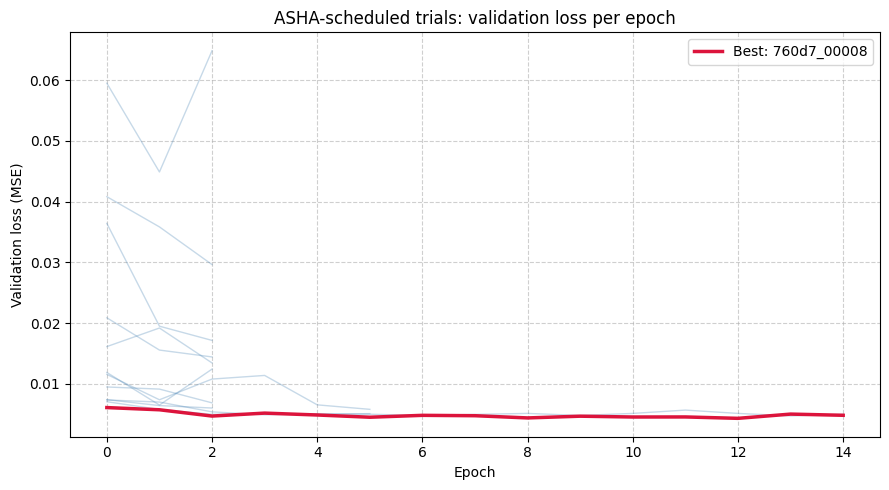

In [34]:
# Plot the validation-loss learning curves for every trial, highlighting the best one.
fig, ax = plt.subplots(figsize=(9, 5))

# Get the best trial ID from the results object
best_trial = results.get_best_trial(metric="val_loss", mode="min")
best_trial_id = best_trial.trial_id
print(f"Plotting {len(results.trials)} trials. Best trial ID: {best_trial_id}")

# First pass: plot all non-best trials in blue with high transparency
for trial in results.trials:
    if trial.trial_id == best_trial_id:
        continue
    df = results.trial_dataframes.get(trial.trial_id)
    if df is not None and "val_loss" in df.columns and not df.empty:
        ax.plot(df["epoch"], df["val_loss"], color="steelblue", linewidth=1.0, alpha=0.3)

# Second pass: plot the best trial in crimson on top
best_df = results.trial_dataframes.get(best_trial_id)
if best_df is not None:
    ax.plot(best_df["epoch"], best_df["val_loss"], color="crimson", linewidth=2.5, alpha=1.0, label=f"Best: {best_trial_id}")

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation loss (MSE)")
ax.set_title("ASHA-scheduled trials: validation loss per epoch")
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()

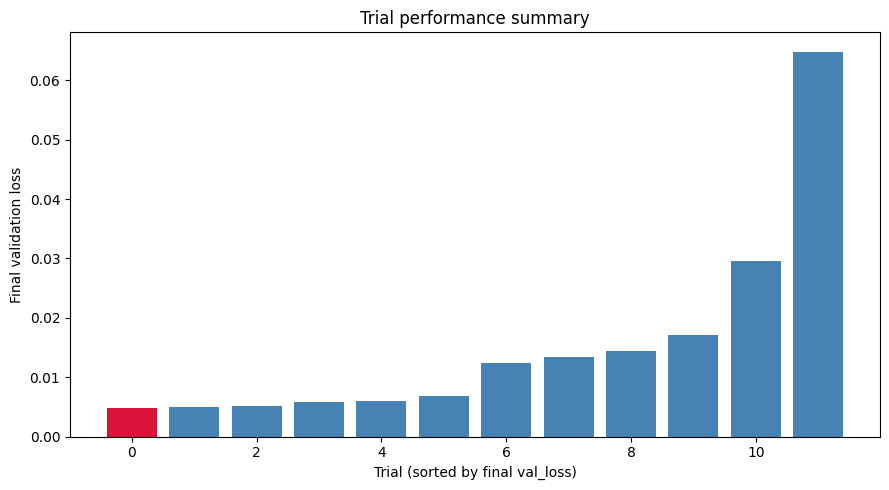

,config/model_type,config/hidden_size,config/num_layers,config/lr,config/dropout,config/batch_size,val_loss
0,lstm,128,1,0.000885,0.147591,256,0.004850
1,lstm,32,2,0.002813,0.120926,256,0.005011
2,cnn,128,1,0.001797,0.007284,64,0.005125
3,lstm,32,2,0.001899,0.211178,128,0.005830
4,lstm,128,1,0.002043,0.285813,128,0.006047
5,lstm,64,2,0.003046,0.463355,128,0.006896
6,lstm,64,2,0.001907,0.406815,64,0.012452
7,cnn,64,1,0.006663,0.260694,128,0.013463
8,cnn,32,2,0.001009,0.281814,128,0.014453
9,cnn,32,1,0.000796,0.188905,128,0.017173


In [37]:
# Summarize final performance across all trials as a bar chart, sorted best-to-worst.
result_df = results.results_df
result_df = result_df.sort_values("val_loss").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["crimson" if i == 0 else "steelblue" for i in range(len(result_df))]
ax.bar(range(len(result_df)), result_df["val_loss"], color=colors)
ax.set_xlabel("Trial (sorted by final val_loss)")
ax.set_ylabel("Final validation loss")
ax.set_title("Trial performance summary")
plt.tight_layout()
plt.show()

result_df[["config/model_type", "config/hidden_size", "config/num_layers",
           "config/lr", "config/dropout", "config/batch_size", "val_loss"]].head(10)

In [38]:
# Clean resource teardown: release the Ray cluster and clear the driver's CUDA cache.
ray.shutdown()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Ray cluster shut down and CUDA cache cleared.")

Ray cluster shut down and CUDA cache cleared.


## Summary

- **cuDF** turned rolling/lag/groupby feature engineering over 500k rows into a sub-second GPU operation, so preprocessing never gates the HPO loop.
- **Fractional GPU allocation** (`gpu=0.33` per trial) let Ray Tune run 3 PyTorch trials concurrently on Colab's single GPU instead of one at a time — roughly a 3x increase in trials explored per hour.
- **ASHA** killed weak trials early, further concentrating GPU time on promising configurations.
- Together, these techniques make serious HPO practical on the single-GPU budgets typical of Colab, a laptop, or a single cloud instance — no multi-GPU cluster required.